# 02_baseline_cnn.ipynb — HistoBreastNet

CNN **addestrata da zero**, usata come baseline per la classificazione binaria benigno/maligno. Il notebook **consuma** gli split e le fold prodotti da `01_preprocessing.ipynb` (config `diversity_1p5GB`) e **non li rigenera**: gli stessi file sono la base comune anche per gli esperimenti successivi.

**Cosa produce**
- Baseline CNN valutata su tre protocolli: image-wise, patient-wise, k-fold patient-wise (k=5).
- Metriche predittive: accuracy, precision (macro), recall (macro), F1 (macro), AUROC, recall della classe maligna (sensibilità clinica), confusion matrix.
- Metriche di efficienza: numero di parametri, tempo totale e medio per epoca di training, tempo di inferenza per immagine, dimensione del modello su disco.
- Tabella finale `results/02_baseline_cnn/tables/cnn_baseline_metrics.csv` (schema fisso) e sintesi k-fold (media ± std).

**Nota sulla valutazione.** Con pochi pazienti il singolo split patient-wise ha varianza elevata: il riferimento per la generalizzazione a pazienti non visti è la **k-fold patient-wise** (media ± std), non il singolo split.

## Sezione 0 — Setup, path, riproducibilità

Import delle librerie, montaggio di Google Drive, impostazione dei seed per la riproducibilità e definizione dei path di progetto e degli iperparametri della baseline. Il flag `LOAD_EXISTING_MODELS_ONLY` distingue tra la riesecuzione del training e il semplice caricamento dei modelli già addestrati.

In [1]:
import os, sys, gc, time, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# ----- Riproducibilità ------------------------------------------------------
RANDOM_STATE = 42
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
keras.utils.set_random_seed(RANDOM_STATE)
# Determinismo completo (più lento): scommenta se serve bit-per-bit reproducibility.
# tf.config.experimental.enable_op_determinism()

# ----- Path progetto --------------------------------------------------------
PROJECT_ROOT   = Path('/content/drive/MyDrive/HistoBreastNet')
DATA_PROCESSED = PROJECT_ROOT/'data'/'processed'
CONFIG_NAME    = 'diversity_1p5GB'            # config principale per la baseline
CONFIG_DIR     = DATA_PROCESSED/CONFIG_NAME
RESULTS_DIR     = PROJECT_ROOT/'results'
NB_RESULTS_DIR  = RESULTS_DIR/'02_baseline_cnn'   # tutti gli output di questo notebook qui sotto
TABLES_DIR      = NB_RESULTS_DIR/'tables'
FIGURES_DIR     = NB_RESULTS_DIR/'figures'
PREDICTIONS_DIR = NB_RESULTS_DIR/'predictions'    # predizioni per-immagine (per la ROC del notebook 03)
EXPERIMENTS_DIR = PROJECT_ROOT/'experiments'      # una sottocartella per run (una per esperimento)
for d in (TABLES_DIR, FIGURES_DIR, PREDICTIONS_DIR, EXPERIMENTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

# --- Modalità: solo predizioni da modelli salvati (nessun nuovo training) ---
LOAD_EXISTING_MODELS_ONLY = True
# True  = non riesegue il training; carica i model.keras già salvati e genera solo le predizioni.
# False = esegue il training completo della CNN baseline.

assert CONFIG_DIR.exists(), f'Config non trovata: {CONFIG_DIR} (esegui prima 01_preprocessing).'

# ----- Iperparametri baseline ----------------------------------------------
IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 40            # limite superiore; EarlyStopping ferma prima
PATIENCE   = 8
QUICK_TEST = False         # True = giro rapido per validare la pipeline (2 epoche)
if QUICK_TEST:
    EPOCHS, PATIENCE = 2, 2

AUTOTUNE = tf.data.AUTOTUNE
gpus = tf.config.list_physical_devices('GPU')
print('TF', tf.__version__, '| GPU:', gpus if gpus else 'NESSUNA (attiva runtime GPU su Colab)')
print('Config baseline:', CONFIG_NAME)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TF 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Config baseline: diversity_1p5GB


**Nota sui modelli salvati.** I file `model.keras` non sono versionati nella repository per motivi di dimensione. Se `LOAD_EXISTING_MODELS_ONLY = True`, il notebook richiede che i modelli CNN baseline siano già presenti localmente nella struttura attesa. In alternativa, è possibile rigenerarli eseguendo il training con `LOAD_EXISTING_MODELS_ONLY = False`, se previsto dalla configurazione del notebook.

## Sezione 1 — Disponibilità del subset (immagini)

La baseline legge **solo** le immagini del subset `diversity_1p5GB` prodotte da `01_preprocessing.ipynb`, in `data/processed/diversity_1p5GB/images/`, e **non** l'intero dataset BreaKHis. I `relative_path` dei CSV partono da `histology_slides/...`, quindi la root si risolve come `DATASET_ROOT / relative_path`.

`READ_MODE`:
- `auto` (default): se esiste `images.zip` su Drive lo estrae in `/content/` (lettura veloce); altrimenti legge direttamente dalla cartella `images/` su Drive (più lento, senza zip);
- `zip`: forza l'estrazione da `images.zip`;
- `drive`: forza la lettura diretta dalla cartella `images/` su Drive.

Se il runtime si disconnette durante l'estrazione è sufficiente rilanciare la cella.

In [ ]:
import zipfile, shutil

# Sorgente = subset creato dal 01 (Sezione 7). NIENTE dataset completo.
SUBSET_IMAGES_DRIVE = CONFIG_DIR/'images'          # data/processed/diversity_1p5GB/images (su Drive)
SUBSET_IMAGES_ZIP   = CONFIG_DIR/'images.zip'      # zip opzionale prodotto dal 01
SUBSET_LOCAL        = Path('/content/subset_images')   # destinazione estrazione veloce

# 'auto' -> zip se presente, altrimenti Drive | 'zip' -> forza zip | 'drive' -> forza Drive
READ_MODE = 'auto'

def _resolve_root(base):
    """La root deve contenere DIRETTAMENTE histology_slides/ (gestisce il prefisso images/)."""
    if (base/'histology_slides').exists():
        return base
    if (base/'images'/'histology_slides').exists():
        return base/'images'
    return None

if READ_MODE == 'zip' and not SUBSET_IMAGES_ZIP.exists():
    raise FileNotFoundError(f'READ_MODE=zip ma manca {SUBSET_IMAGES_ZIP}. '
                            'Crea lo zip nel 01 (Sezione 7, CREATE_IMAGES_ZIP=True).')

use_zip = (READ_MODE in ('auto', 'zip')) and SUBSET_IMAGES_ZIP.exists()

if use_zip:
    shutil.rmtree(SUBSET_LOCAL, ignore_errors=True)
    SUBSET_LOCAL.mkdir(parents=True, exist_ok=True)
    t0 = time.time(); print('Estrazione del subset dallo zip su Drive...')
    with zipfile.ZipFile(SUBSET_IMAGES_ZIP) as z:
        z.extractall(SUBSET_LOCAL)
    DATASET_ROOT = _resolve_root(SUBSET_LOCAL)
    print('Subset estratto in %.0fs -> %s' % (time.time()-t0, DATASET_ROOT))
elif SUBSET_IMAGES_DRIVE.exists():
    DATASET_ROOT = _resolve_root(SUBSET_IMAGES_DRIVE)
    print('Lettura diretta dal subset su Drive (più lento):', SUBSET_IMAGES_DRIVE)
else:
    raise FileNotFoundError(
        'Subset non trovato. Esegui prima 01_preprocessing.ipynb (Sezione 7) per creare '
        f'{SUBSET_IMAGES_DRIVE} (e opzionalmente {SUBSET_IMAGES_ZIP}).')

if DATASET_ROOT is None:
    raise FileNotFoundError('Non trovo histology_slides/ nel subset: struttura inattesa.')

# Integrità: il numero di PNG deve combaciare con metadata_subset.csv (subset, non 7909)
n_sub = sum(1 for _ in DATASET_ROOT.rglob('*.png'))
n_csv = len(pd.read_csv(CONFIG_DIR/'metadata_subset.csv'))
assert n_sub == n_csv, f'Subset incompleto: {n_sub} PNG trovati, {n_csv} attesi (metadata_subset.csv).'
print('DATASET_ROOT:', DATASET_ROOT, '| immagini subset:', n_sub, '-> OK ✓')

Estrazione del subset dallo zip su Drive...
Subset estratto in 41s -> /content/subset_images/images
DATASET_ROOT: /content/subset_images/images | immagini subset: 2838 -> OK ✓


## Sezione 2 — Caricamento degli split/fold e ricostruzione dei path

Si leggono i CSV della configurazione e si ricostruisce il path assoluto a partire da `relative_path` (`full_path = DATASET_ROOT / relative_path`). I path assoluti salvati dal notebook 01 (colonna `path`) vengono ignorati, così il notebook resta portabile tra sessioni diverse.

In [ ]:
def add_full_path(df):
    """Aggiunge full_path da relative_path e resetta l'indice (ordine stabile)."""
    df = df.copy()
    df['full_path'] = df['relative_path'].map(lambda r: str(DATASET_ROOT / r))
    return df.reset_index(drop=True)

# Sanity: i file referenziati esistono davvero
_probe = add_full_path(pd.read_csv(CONFIG_DIR/'metadata_subset.csv'))
_missing = [p for p in _probe['full_path'].sample(min(50, len(_probe)), random_state=RANDOM_STATE)
            if not Path(p).exists()]
assert not _missing, f'File non trovati (esempio): {_missing[:3]}'
print('metadata_subset:', len(_probe), 'immagini |', _probe['patient_id'].nunique(), 'pazienti')
print('Distribuzione classi (immagini):', _probe['binary_label'].value_counts().to_dict(),
      ' (0=benign, 1=malignant)')

with open(CONFIG_DIR/'config.json') as f:
    CFG = json.load(f)
print('config.json ->', {k: CFG[k] for k in
      ('n_patients','n_images','actual_size_gib','n_patients_benign','n_patients_malignant')})

metadata_subset: 2838 immagini | 33 pazienti
Distribuzione classi (immagini): {0: 1431, 1: 1407}  (0=benign, 1=malignant)
config.json -> {'n_patients': 33, 'n_images': 2838, 'actual_size_gib': 1.483, 'n_patients_benign': 15, 'n_patients_malignant': 18}


## Sezione 3 — Pipeline `tf.data`

Decodifica PNG → resize 224×224 → cache in `uint8` (memoria-efficiente) → normalizzazione in [0,1]. L'augmentation (flip e variazioni leggere di luminosità e contrasto) è applicata **solo al training**. Validation e test non vengono mescolati: l'ordine delle predizioni coincide con quello dei DataFrame, condizione necessaria per associare correttamente ogni predizione alla sua immagine.

In [ ]:
def _decode_uint8(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE], method='bilinear')
    img = tf.cast(img, tf.uint8)                      # cache leggera (~1 byte/px)
    return img, label

def _to_float(img, label):
    return tf.cast(img, tf.float32) / 255.0, label

def _augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.05)
    img = tf.image.random_contrast(img, 0.95, 1.05)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def make_ds(df, training=False, augment=False, batch=BATCH_SIZE):
    paths  = df['full_path'].values
    labels = df['binary_label'].values.astype('float32')
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(_decode_uint8, num_parallel_calls=AUTOTUNE).cache()
    # shuffle solo in training; su validation/test l'ordine resta stabile
    # per mantenere l'allineamento tra predizioni e righe del DataFrame.
    if training:
        ds = ds.shuffle(min(len(df), 2048), seed=RANDOM_STATE, reshuffle_each_iteration=True)
    ds = ds.map(_to_float, num_parallel_calls=AUTOTUNE)
    # augmentation applicata dopo la normalizzazione e solo quando richiesta.
    if augment:
        ds = ds.map(_augment, num_parallel_calls=AUTOTUNE)
    return ds.batch(batch).prefetch(AUTOTUNE)

## Sezione 4 — Architettura CNN da zero e training

CNN volutamente compatta (4 blocchi Conv-BN-ReLU-Pool, seguiti da global average pooling e da una testa densa), adeguata a un dataset di dimensioni ridotte per limitare l'overfitting. L'uscita è sigmoide (classificazione binaria). Il `class_weight` bilanciato evita di penalizzare la classe maligna, sotto-rappresentata. L'`EarlyStopping` monitora `val_auc` e ripristina i pesi migliori.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

def build_baseline_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), seed=RANDOM_STATE):
    keras.utils.set_random_seed(seed)               # init pesi riproducibile
    inp = layers.Input(shape=input_shape)
    x = inp
    # quattro blocchi convoluzionali a filtri crescenti; BatchNormalization
    # stabilizza il training, il pooling riduce progressivamente la risoluzione.
    for f in (32, 64, 128, 128):
        x = layers.Conv2D(f, 3, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.40)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.30)(x)
    # singola uscita sigmoide: probabilità della classe maligna.
    out = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inp, out, name='baseline_cnn')

class TimeHistory(keras.callbacks.Callback):
    """Registra il tempo di ogni epoca per calcolare avg_epoch_time_sec."""
    def on_train_begin(self, logs=None): self.times = []
    def on_epoch_begin(self, epoch, logs=None): self._t = time.time()
    def on_epoch_end(self, epoch, logs=None): self.times.append(time.time() - self._t)

def class_weights_from(df):
    y = df['binary_label'].values
    w = compute_class_weight('balanced', classes=np.array([0, 1]), y=y)
    return {0: float(w[0]), 1: float(w[1])}

def train_cnn(train_df, val_df, seed=RANDOM_STATE):
    train_ds = make_ds(train_df, training=True, augment=True)
    val_ds   = make_ds(val_df,   training=False, augment=False)
    model = build_baseline_cnn(seed=seed)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=[keras.metrics.AUC(name='auc'), 'accuracy'])
    th = TimeHistory()
    # EarlyStopping su val_auc (robusta allo sbilanciamento) con ripristino dei pesi
    # migliori; ReduceLROnPlateau riduce il learning rate quando la val_loss ristagna.
    cbs = [keras.callbacks.EarlyStopping(monitor='val_auc', mode='max',
                                         patience=PATIENCE, restore_best_weights=True),
           keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                             patience=4, min_lr=1e-5),
           th]
    t0 = time.time()
    hist = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS,
                     class_weight=class_weights_from(train_df), callbacks=cbs, verbose=2)
    train_time = time.time() - t0
    return model, hist, th, train_time

## Sezione 5 — Metriche predittive, efficienza e valutazione

**Convenzione sulle metriche.** `precision`, `recall` e `f1` sono calcolate in modalità **macro** (media sulle due classi, vista bilanciata); `recall_malignant` è la recall della sola classe maligna (sensibilità, metrica clinicamente critica); `auroc` è calcolata sulle probabilità. La confusion matrix è salvata come `tn`/`fp`/`fn`/`tp`.

**Efficienza (D1).** `n_params` dal modello; `training_time_sec` misurato a muro; `avg_epoch_time_sec` come media reale delle epoche eseguite; `inference_time_ms_per_image` come throughput a regime su batch (preceduto da un warm-up); `model_size_mb` dalla dimensione del file `.keras` salvato su disco.

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)
from datetime import datetime

# --- Esperimenti: una cartella per run in experiments/ ----------------------
# Convenzione di naming della cartella:
#   <YYYYMMDD_HHMMSS_micros>_<dataset_config>_<split_type>_baseline_cnn_scratch_fold<N>
# Contenuto: config.json, model.keras, training_log.csv, metrics.csv
def make_experiment_dir(split_type, fold):
    fold_tag = 'NA' if pd.isna(fold) else int(fold)
    ts = datetime.now().strftime('%Y%m%d_%H%M%S_%f')
    name = f'{ts}_{CONFIG_NAME}_{split_type}_baseline_cnn_scratch_fold{fold_tag}'
    d = EXPERIMENTS_DIR/name
    d.mkdir(parents=True, exist_ok=True)
    return d

def save_training_log(exp_dir, hist, th):
    log = pd.DataFrame(hist.history)
    log.insert(0, 'epoch', range(1, len(log) + 1))
    if th.times and len(th.times) == len(log):
        log['epoch_time_sec'] = th.times
    log.to_csv(exp_dir/'training_log.csv', index=False)

def save_experiment_config(exp_dir, split_type, fold, sizes):
    cfg = dict(
        dataset_config=CONFIG_NAME, split_type=split_type,
        fold=(None if pd.isna(fold) else int(fold)),
        model='baseline_cnn', training_mode='from_scratch',
        image_size=[IMG_SIZE, IMG_SIZE], batch_size=BATCH_SIZE, seed=RANDOM_STATE,
        max_epochs=EPOCHS, patience=PATIENCE,
        optimizer='adam', learning_rate=1e-3, loss='binary_crossentropy',
        class_weight='balanced', quick_test=QUICK_TEST,
        source_config_dir=str(CONFIG_DIR),
        **sizes,
    )
    with open(exp_dir/'config.json', 'w') as f:
        json.dump(cfg, f, indent=2)


# Metriche predittive: versione macro (vista bilanciata sulle due classi) più
# la recall della sola classe maligna, clinicamente prioritaria.
def compute_metrics(y_true, y_prob, thr=0.5):
    y_pred = (y_prob >= thr).astype(int)
    out = dict(
        accuracy=accuracy_score(y_true, y_pred),
        precision=precision_score(y_true, y_pred, average='macro', zero_division=0),
        recall=recall_score(y_true, y_pred, average='macro', zero_division=0),
        f1=f1_score(y_true, y_pred, average='macro', zero_division=0),
        recall_malignant=recall_score(y_true, y_pred, pos_label=1, zero_division=0),
    )
    try:
        out['auroc'] = roc_auc_score(y_true, y_prob)
    except ValueError:                                # test con una sola classe
        out['auroc'] = np.nan
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    out.update(tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp))
    return out

def measure_inference_ms(model, test_ds, n_images):
    _ = model.predict(test_ds, verbose=0)             # warm-up (grafo/JIT)
    t0 = time.perf_counter()
    _ = model.predict(test_ds, verbose=0)
    return (time.perf_counter() - t0) * 1000.0 / n_images

def run_cnn(split_type, fold, train_df, val_df, test_df):
    tf.keras.backend.clear_session()
    model, hist, th, train_time = train_cnn(train_df, val_df)

    test_ds = make_ds(test_df, training=False, augment=False)
    y_true  = test_df['binary_label'].values
    y_prob  = model.predict(test_ds, verbose=0).ravel()

    fold_tag = 'NA' if pd.isna(fold) else int(fold)
    exp_dir  = make_experiment_dir(split_type, fold)      # experiments/<timestamp>_.../
    ckpt = exp_dir/'model.keras'
    model.save(ckpt)
    sizes = dict(n_train=len(train_df), n_val=len(val_df), n_test=len(test_df))
    save_training_log(exp_dir, hist, th)                  # training_log.csv (andamento fit)
    save_experiment_config(exp_dir, split_type, fold, sizes)  # config.json (iperparametri)

    row = dict(dataset_config=CONFIG_NAME, split_type=split_type, fold=fold,
               model='baseline_cnn', training_mode='from_scratch',
               experiment=exp_dir.name)
    row.update(compute_metrics(y_true, y_prob))
    row.update(
        training_time_sec=round(train_time, 2),
        avg_epoch_time_sec=round(float(np.mean(th.times)), 2) if th.times else np.nan,
        inference_time_ms_per_image=round(measure_inference_ms(model, test_ds, len(test_df)), 3),
        n_params=int(model.count_params()),
        model_size_mb=round(ckpt.stat().st_size / 1e6, 2),
        n_train=len(train_df), n_val=len(val_df), n_test=len(test_df),
        epochs_run=len(th.times), notes='',
    )
    pd.DataFrame([row]).to_csv(exp_dir/'metrics.csv', index=False)  # metriche del singolo run
    print(f'[CNN] {split_type} fold={fold_tag}: '
          f"AUROC={row['auroc'] if pd.isna(row['auroc']) else round(row['auroc'],3)} "
          f"acc={row['accuracy']:.3f} rec_mal={row['recall_malignant']:.3f} "
          f"({row['epochs_run']} epoche, {row['training_time_sec']:.0f}s)")
    del model; gc.collect()
    return row

## Sezione 6 — Enumerazione dei protocolli di valutazione

Viene costruita un'unica lista di run `(split_type, fold, train, val, test)` **esclusivamente** a partire dai CSV prodotti dal notebook 01: image-wise (1 split), patient-wise (1 split) e k-fold patient-wise (5 fold). Nessuno split viene rigenerato in questo notebook.

In [ ]:
def enumerate_runs():
    runs = []

    iw = add_full_path(pd.read_csv(CONFIG_DIR/'image_wise_split.csv'))
    runs.append(('image_wise', np.nan,
                 iw[iw.split=='train'], iw[iw.split=='val'], iw[iw.split=='test']))

    pw = add_full_path(pd.read_csv(CONFIG_DIR/'patient_wise_split.csv'))
    runs.append(('patient_wise', np.nan,
                 pw[pw.split=='train'], pw[pw.split=='val'], pw[pw.split=='test']))

    kf = add_full_path(pd.read_csv(CONFIG_DIR/'patient_wise_folds.csv'))
    for fo in sorted(kf['fold'].unique()):
        f = kf[kf.fold == fo]
        runs.append(('kfold_patient_wise', int(fo),
                     f[f.split=='train'], f[f.split=='val'], f[f.split=='test']))
    return runs

# I run sono costruiti direttamente dai CSV del notebook 01: nessuno split
# viene rigenerato qui, per garantire coerenza tra i due notebook.
RUNS = enumerate_runs()
print('Protocolli di valutazione:')
for st, fo, tr, va, te in RUNS:
    ft = 'NA' if pd.isna(fo) else int(fo)
    print(f'  {st:20s} fold={ft:>2}  train={len(tr):4d}  val={len(va):3d}  test={len(te):3d}  '
          f"(test pazienti: {te['patient_id'].nunique()})")

Protocolli di valutazione:
  image_wise           fold=NA  train=1986  val=426  test=426  (test pazienti: 33)
  patient_wise         fold=NA  train=1798  val=418  test=622  (test pazienti: 5)
  kfold_patient_wise   fold= 0  train=1914  val=428  test=496  (test pazienti: 7)
  kfold_patient_wise   fold= 1  train=1782  val=322  test=734  (test pazienti: 7)
  kfold_patient_wise   fold= 2  train=1913  val=330  test=595  (test pazienti: 7)
  kfold_patient_wise   fold= 3  train=1948  val=326  test=564  (test pazienti: 6)
  kfold_patient_wise   fold= 4  train=1928  val=461  test=449  (test pazienti: 6)


In [ ]:
# Controllo di sicurezza: nessun overlap di pazienti tra train/val/test
# nei protocolli patient-wise e k-fold patient-wise. Non cambia alcun risultato.
def assert_patient_disjoint(train_df, val_df, test_df, name):
    train_p = set(train_df['patient_id'])
    val_p   = set(val_df['patient_id'])
    test_p  = set(test_df['patient_id'])
    assert train_p.isdisjoint(val_p),  f"{name}: overlap pazienti train/val"
    assert train_p.isdisjoint(test_p), f"{name}: overlap pazienti train/test"
    assert val_p.isdisjoint(test_p),   f"{name}: overlap pazienti val/test"

for st, fo, tr, va, te in RUNS:
    if st in ('patient_wise', 'kfold_patient_wise'):
        fold_tag = 'NA' if pd.isna(fo) else int(fo)
        assert_patient_disjoint(tr, va, te, f'{st} fold={fold_tag}')

print('Controllo patient-wise: nessun overlap train/val/test nei protocolli patient-wise.')

Controllo patient-wise: nessun overlap train/val/test nei protocolli patient-wise.


## Sezione 7 — Addestramento della baseline CNN su tutti i protocolli

I tempi possono essere significativi: su GPU Colab servono circa 5–8 minuti per fold, e l'intero blocco (7 run) può richiedere 30–60 minuti. Impostando `QUICK_TEST=True` nella Sezione 0 si esegue una prova rapida di correttezza in pochi minuti.

**Output per run.** Ogni fold produce una cartella `experiments/<timestamp>_<config>_<split>_baseline_cnn_scratch_fold<N>/` contenente `config.json`, `model.keras`, `training_log.csv` e `metrics.csv`. Le tabelle aggregate di confronto restano in `results/02_baseline_cnn/tables/` (Sezione 8).

In [ ]:
if LOAD_EXISTING_MODELS_ONLY:
    print("LOAD_EXISTING_MODELS_ONLY=True: salto il training CNN e userò i modelli salvati.")
    cnn_results = None
else:
    cnn_results = [run_cnn(st, fo, tr, va, te) for (st, fo, tr, va, te) in RUNS]
    print('\nCNN completata:', len(cnn_results), 'run.')

LOAD_EXISTING_MODELS_ONLY=True: salto il training CNN e userò i modelli salvati.


## Sezione 8 — Tabella finale e sintesi k-fold (D1/D2)

Viene salvata `results/02_baseline_cnn/tables/cnn_baseline_metrics.csv` con lo schema previsto (con in coda le colonne `tn`/`fp`/`fn`/`tp` e alcune dimensioni utili). Viene inoltre calcolata la sintesi media ± std sulle 5 fold della CNN: è il valore da riportare per la generalizzazione a pazienti non visti (D2), preferibile al singolo split.

In [2]:
if LOAD_EXISTING_MODELS_ONLY:
    metrics_path = TABLES_DIR / "cnn_baseline_metrics.csv"
    summary_path = TABLES_DIR / "cnn_baseline_kfold_summary.csv"

    if not metrics_path.exists():
        raise FileNotFoundError(
            f"LOAD_EXISTING_MODELS_ONLY=True ma manca {metrics_path}. "
            "Servono le metriche già generate per trovare le cartelle experiments."
        )

    df = pd.read_csv(metrics_path)
    print("Metriche CNN baseline caricate da:", metrics_path)
    if summary_path.exists():
        summary = pd.read_csv(summary_path)
        print("Summary k-fold caricata da:", summary_path)
else:
    REQUIRED = ['dataset_config','split_type','fold','model','training_mode','accuracy',
                'precision','recall','f1','auroc','recall_malignant','training_time_sec',
                'avg_epoch_time_sec','inference_time_ms_per_image','n_params','model_size_mb']
    EXTRA = ['tn','fp','fn','tp','n_train','n_val','n_test','epochs_run','experiment','notes']

    df = pd.DataFrame(cnn_results)
    df = df.reindex(columns=REQUIRED + EXTRA)
    out_csv = TABLES_DIR/'cnn_baseline_metrics.csv'
    df.to_csv(out_csv, index=False)
    print('Salvato:', out_csv, '|', df.shape)

    # ---- Sintesi k-fold: media +/- std per modello (D2) ------------------------
    kf = df[df.split_type == 'kfold_patient_wise']
    agg_cols = ['accuracy','precision','recall','f1','auroc','recall_malignant',
                'training_time_sec','inference_time_ms_per_image']
    summary = (kf.groupby('model')[agg_cols]
                 .agg(['mean','std']).round(4))
    summary.columns = [f'{m}_{s}' for m, s in summary.columns]
    summary = summary.reset_index()
    summary.insert(0, 'dataset_config', CONFIG_NAME)
    summary.insert(2, 'split_type', 'kfold_patient_wise')
    summary.insert(3, 'k', kf['fold'].nunique())
    summary_csv = TABLES_DIR/'cnn_baseline_kfold_summary.csv'
    summary.to_csv(summary_csv, index=False)
    print('Salvato:', summary_csv)


# ---- Visualizzazione delle metriche principali -----------------------------
metric_cols = [
    "split_type",
    "fold",
    "model",
    "accuracy",
    "f1",
    "auroc",
    "recall_malignant",
    "recall_benign",
    "inference_time_ms_per_image",
]
available_metric_cols = [c for c in metric_cols if c in df.columns]

print("Metriche principali della CNN baseline:")
display(df[available_metric_cols] if available_metric_cols else df)

if "summary" in globals():
    print("Sintesi k-fold patient-wise:")
    display(summary)


Metriche CNN baseline caricate da: /content/drive/MyDrive/HistoBreastNet/results/02_baseline_cnn/tables/cnn_baseline_metrics.csv
Summary k-fold caricata da: /content/drive/MyDrive/HistoBreastNet/results/02_baseline_cnn/tables/cnn_baseline_kfold_summary.csv
Metriche principali della CNN baseline:


,split_type,fold,model,accuracy,f1,auroc,recall_malignant,inference_time_ms_per_image
0,image_wise,NaN,baseline_cnn,0.875587,0.875284,0.962592,0.933649,0.489
1,patient_wise,NaN,baseline_cnn,0.557878,0.358101,0.936484,0.000000,0.500
2,kfold_patient_wise,0.0,baseline_cnn,0.600806,0.519530,0.820262,0.191837,0.624
3,kfold_patient_wise,1.0,baseline_cnn,0.724796,0.721144,0.764187,0.903226,0.458
4,kfold_patient_wise,2.0,baseline_cnn,0.531092,0.346872,0.769475,1.000000,0.483
5,kfold_patient_wise,3.0,baseline_cnn,0.735816,0.727063,0.869473,0.514754,0.556
6,kfold_patient_wise,4.0,baseline_cnn,0.899777,0.899769,0.955402,1.000000,0.686


Sintesi k-fold patient-wise:


,dataset_config,model,split_type,k,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,auroc_mean,auroc_std,recall_malignant_mean,recall_malignant_std,training_time_sec_mean,training_time_sec_std,inference_time_ms_per_image_mean,inference_time_ms_per_image_std
0,diversity_1p5GB,baseline_cnn,kfold_patient_wise,5,0.6985,0.1416,0.7053,0.2524,0.6995,0.1575,0.6429,0.2133,0.8358,0.0794,0.722,0.3576,96.686,21.7901,0.5614,0.0953


## Sezione 8b — Predizioni out-of-fold dai modelli CNN salvati

Questa sezione non allena nuovi modelli. Usa `cnn_baseline_metrics.csv` per individuare le cartelle `experiments/`, carica i `model.keras` già salvati e genera le predizioni per immagine della baseline sulle fold k-fold patient-wise. Il file `cnn_baseline_predictions.csv` permette di inserire la baseline nella curva ROC e nei grafici aggregati del notebook 03.

In [ ]:
def _available_columns(df, cols):
    return [c for c in cols if c in df.columns]


def _fold_to_test_df_from_runs(runs):
    mapping = {}
    for split_type, fold, train_df, val_df, test_df in runs:
        if split_type == "kfold_patient_wise":
            mapping[int(fold)] = test_df.copy().reset_index(drop=True)
    return mapping


def _load_saved_baseline_model_for_fold(metrics_df, fold):
    required_cols = ["split_type", "model", "training_mode", "fold", "experiment"]
    missing = [c for c in required_cols if c not in metrics_df.columns]
    if missing:
        raise ValueError(f"cnn_baseline_metrics.csv manca colonne richieste: {missing}")

    rows = metrics_df[
        (metrics_df["split_type"].astype(str) == "kfold_patient_wise")
        & (metrics_df["model"].astype(str) == "baseline_cnn")
        & (metrics_df["training_mode"].astype(str) == "from_scratch")
    ].copy()

    rows["fold_int"] = pd.to_numeric(rows["fold"], errors="coerce").astype("Int64")
    rows = rows[rows["fold_int"] == int(fold)].copy()

    if rows.empty:
        raise FileNotFoundError(
            f"Nessuna riga baseline CNN k-fold trovata in metrics per fold {fold}."
        )

    # Se ci sono più righe, usa l'ultima nel CSV.
    exp_name = rows.iloc[-1]["experiment"]
    exp_dir = EXPERIMENTS_DIR / str(exp_name)
    model_path = exp_dir / "model.keras"

    if not model_path.exists():
        raise FileNotFoundError(
            f"Modello non trovato per fold {fold}: {model_path}. "
            "Controlla che experiments/ contenga le cartelle originali."
        )

    return model_path


# Predizioni out-of-fold: ogni immagine viene predetta dal modello della fold
# in cui appartiene al test, ricaricando i model.keras già salvati (nessun training).
def generate_cnn_baseline_predictions_from_saved_models(
    metrics_df,
    runs,
    output_path=None,
):
    if output_path is None:
        output_path = PREDICTIONS_DIR / "cnn_baseline_predictions.csv"

    fold_to_test_df = _fold_to_test_df_from_runs(runs)
    expected_folds = set(range(5))
    found_folds = set(fold_to_test_df.keys())
    assert found_folds == expected_folds, (
        f"Fold k-fold attese {expected_folds}, trovate {found_folds}"
    )

    all_preds = []

    for fold in sorted(fold_to_test_df):
        test_df = fold_to_test_df[fold].copy().reset_index(drop=True)
        model_path = _load_saved_baseline_model_for_fold(metrics_df, fold)

        print(f"Fold {fold}: carico modello {model_path}")
        model = tf.keras.models.load_model(model_path, compile=False)

        test_ds = make_ds(test_df, training=False, augment=False)
        y_prob = model.predict(test_ds, verbose=0).reshape(-1)

        if len(y_prob) != len(test_df):
            raise ValueError(
                f"Fold {fold}: numero predizioni {len(y_prob)} diverso da test_df {len(test_df)}"
            )

        pred_df = test_df.copy()
        pred_df["dataset_config"] = CONFIG_NAME
        pred_df["split_type"] = "kfold_patient_wise"
        pred_df["fold"] = int(fold)
        pred_df["model"] = "baseline_cnn"
        pred_df["training_mode"] = "from_scratch"
        pred_df["y_true"] = pred_df["binary_label"].astype(int)
        pred_df["y_prob"] = y_prob.astype(float)
        pred_df["y_pred"] = (pred_df["y_prob"] >= 0.5).astype(int)

        desired_cols = [
            "dataset_config",
            "split_type",
            "fold",
            "model",
            "training_mode",
            "relative_path",
            "path",
            "full_path",
            "filename",
            "patient_id",
            "label",
            "binary_label",
            "subtype",
            "subtype_name",
            "magnification",
            "y_true",
            "y_prob",
            "y_pred",
        ]

        pred_df = pred_df[_available_columns(pred_df, desired_cols)]
        all_preds.append(pred_df)

        del model
        tf.keras.backend.clear_session()
        gc.collect()

    cnn_baseline_predictions = pd.concat(all_preds, ignore_index=True)

    kfold_preds = cnn_baseline_predictions[
        cnn_baseline_predictions["split_type"] == "kfold_patient_wise"
    ].copy()

    expected_n_predictions = sum(len(test_df) for test_df in fold_to_test_df.values())
    assert len(kfold_preds) == expected_n_predictions, (
        f"Predizioni k-fold attese: {expected_n_predictions}, trovate: {len(kfold_preds)}"
    )

    assert set(kfold_preds["fold"].dropna().astype(int)) == {0, 1, 2, 3, 4}, (
        "Fold k-fold mancanti o non corrette"
    )

    dup_cols = ["relative_path", "model", "training_mode", "split_type"]
    if all(c in kfold_preds.columns for c in dup_cols):
        assert not kfold_preds.duplicated(subset=dup_cols).any(), (
            "Duplicati nelle predizioni k-fold baseline"
        )

    assert kfold_preds["y_prob"].between(0, 1).all(), (
        "y_prob contiene valori fuori da [0, 1]"
    )

    PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)
    cnn_baseline_predictions.to_csv(output_path, index=False)

    print("Predizioni CNN baseline k-fold salvate correttamente:")
    print(output_path)
    print(kfold_preds.groupby("fold").size())

    return cnn_baseline_predictions


cnn_baseline_predictions = generate_cnn_baseline_predictions_from_saved_models(
    metrics_df=df,
    runs=RUNS,
    output_path=PREDICTIONS_DIR / "cnn_baseline_predictions.csv",
)

# ---- Anteprima leggibile (solo colonne essenziali, niente path lunghi) -----
prediction_preview_cols = [
    "fold",
    "relative_path",
    "patient_id",
    "label",
    "subtype_name",
    "magnification",
    "y_true",
    "y_prob",
    "y_pred",
]
available_prediction_cols = _available_columns(
    cnn_baseline_predictions, prediction_preview_cols
)

display(
    cnn_baseline_predictions[available_prediction_cols].head()
    if available_prediction_cols
    else cnn_baseline_predictions.head()
)


Fold 0: carico modello /content/drive/MyDrive/HistoBreastNet/experiments/20260704_174603_999730_diversity_1p5GB_kfold_patient_wise_baseline_cnn_scratch_fold0/model.keras
Fold 1: carico modello /content/drive/MyDrive/HistoBreastNet/experiments/20260704_174748_334680_diversity_1p5GB_kfold_patient_wise_baseline_cnn_scratch_fold1/model.keras
Fold 2: carico modello /content/drive/MyDrive/HistoBreastNet/experiments/20260704_174912_458835_diversity_1p5GB_kfold_patient_wise_baseline_cnn_scratch_fold2/model.keras
Fold 3: carico modello /content/drive/MyDrive/HistoBreastNet/experiments/20260704_175035_602913_diversity_1p5GB_kfold_patient_wise_baseline_cnn_scratch_fold3/model.keras
Fold 4: carico modello /content/drive/MyDrive/HistoBreastNet/experiments/20260704_175236_679671_diversity_1p5GB_kfold_patient_wise_baseline_cnn_scratch_fold4/model.keras
Predizioni CNN baseline k-fold salvate correttamente:
/content/drive/MyDrive/HistoBreastNet/results/02_baseline_cnn/predictions/cnn_baseline_predictio

,dataset_config,split_type,fold,model,training_mode,relative_path,path,full_path,filename,patient_id,label,binary_label,subtype,subtype_name,magnification,y_true,y_prob,y_pred
0,diversity_1p5GB,kfold_patient_wise,0,baseline_cnn,from_scratch,histology_slides/breast/benign/SOB/adenosis/SO...,/content/breakhis/BreaKHis_v1/histology_slides...,/content/subset_images/images/histology_slides...,SOB_B_A-14-22549AB-100-009.png,SOB_B_A_14-22549AB,benign,0,A,adenosis,100X,0,0.014031,0
1,diversity_1p5GB,kfold_patient_wise,0,baseline_cnn,from_scratch,histology_slides/breast/benign/SOB/adenosis/SO...,/content/breakhis/BreaKHis_v1/histology_slides...,/content/subset_images/images/histology_slides...,SOB_B_A-14-22549AB-100-029.png,SOB_B_A_14-22549AB,benign,0,A,adenosis,100X,0,0.002022,0
2,diversity_1p5GB,kfold_patient_wise,0,baseline_cnn,from_scratch,histology_slides/breast/benign/SOB/adenosis/SO...,/content/breakhis/BreaKHis_v1/histology_slides...,/content/subset_images/images/histology_slides...,SOB_B_A-14-22549AB-100-012.png,SOB_B_A_14-22549AB,benign,0,A,adenosis,100X,0,0.003424,0
3,diversity_1p5GB,kfold_patient_wise,0,baseline_cnn,from_scratch,histology_slides/breast/benign/SOB/adenosis/SO...,/content/breakhis/BreaKHis_v1/histology_slides...,/content/subset_images/images/histology_slides...,SOB_B_A-14-22549AB-100-015.png,SOB_B_A_14-22549AB,benign,0,A,adenosis,100X,0,0.002065,0
4,diversity_1p5GB,kfold_patient_wise,0,baseline_cnn,from_scratch,histology_slides/breast/benign/SOB/adenosis/SO...,/content/breakhis/BreaKHis_v1/histology_slides...,/content/subset_images/images/histology_slides...,SOB_B_A-14-22549AB-100-003.png,SOB_B_A_14-22549AB,benign,0,A,adenosis,100X,0,0.002811,0


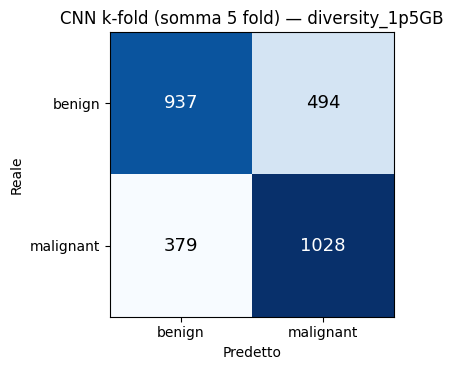

Recall maligni aggregata (TP/(TP+FN)): 0.731


In [ ]:
# Confusion matrix aggregata sulle 5 fold (solo CNN) per lettura D2
cnn_kf = df[(df.split_type=='kfold_patient_wise') & (df.model=='baseline_cnn')]
tn, fp, fn, tp = [int(cnn_kf[c].sum()) for c in ('tn','fp','fn','tp')]
cm = np.array([[tn, fp], [fn, tp]])

fig, ax = plt.subplots(figsize=(4.2, 3.8))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1], ['benign','malignant']); ax.set_yticks([0,1], ['benign','malignant'])
ax.set_xlabel('Predetto'); ax.set_ylabel('Reale')
ax.set_title(f'CNN k-fold (somma 5 fold) — {CONFIG_NAME}')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR/'cnn_kfold_confusion_matrix.png', dpi=150)
plt.show()
print('Recall maligni aggregata (TP/(TP+FN)):', round(tp/(tp+fn), 3))

## Sezione 9 — Analisi D2: image-wise vs patient-wise

La seconda domanda di ricerca valuta se le prestazioni della CNN baseline restano affidabili quando il modello viene valutato su **pazienti non visti**.

Per questo confrontiamo tre protocolli:

- **Image-wise split**: le immagini vengono divise casualmente. Può produrre una stima ottimistica perché immagini dello stesso paziente possono comparire sia in train sia in test.
- **Patient-wise split singolo**: separa i pazienti tra train, validation e test. È più realistico, ma può essere molto instabile perché dipende da una singola divisione dei pazienti.
- **5-fold patient-wise**: ripete la valutazione su cinque split patient-wise. È il riferimento principale perché riduce la dipendenza da una singola partizione.

Il simbolo **±** indica **media ± deviazione standard** sui cinque fold patient-wise. La deviazione standard misura quanto le prestazioni cambiano tra fold diversi.

In [3]:
# ==============================
# D2 — Summary table
# ==============================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Se il dataframe df non è in memoria, caricalo dal CSV
metrics_path = TABLES_DIR / "cnn_baseline_metrics.csv"
assert metrics_path.exists(), f"File non trovato: {metrics_path}"

if "df" not in globals():
    df = pd.read_csv(metrics_path)

# Normalizza fold e split_type
df = df.copy()
df["split_type"] = df["split_type"].astype(str)

# Manteniamo solo la CNN baseline addestrata da zero
if "model" in df.columns:
    df = df[df["model"].astype(str) == "baseline_cnn"].copy()

if "training_mode" in df.columns:
    df = df[df["training_mode"].astype(str) == "from_scratch"].copy()

# Se per qualche motivo esistono più run per lo stesso split/fold,
# teniamo l'ultima riga disponibile.
sort_cols = [c for c in ["experiment", "fold"] if c in df.columns]
if sort_cols:
    df = df.sort_values(sort_cols)

df = df.drop_duplicates(
    subset=["split_type", "fold"],
    keep="last"
).copy()

metric_cols = ["accuracy", "precision", "recall", "f1", "auroc", "recall_malignant"]
count_cols = ["tn", "fp", "fn", "tp"]

for col in metric_cols + count_cols:
    assert col in df.columns, f"Colonna mancante nel CSV: {col}"

image_row = df[df["split_type"] == "image_wise"].iloc[0]
patient_row = df[df["split_type"] == "patient_wise"].iloc[0]
kfold_df = df[df["split_type"] == "kfold_patient_wise"].copy()

assert len(kfold_df) == 5, f"Attesi 5 fold patient-wise, trovati {len(kfold_df)}"

kfold_mean = kfold_df[metric_cols].mean()
kfold_std = kfold_df[metric_cols].std()

def fmt_value(x):
    return f"{x:.3f}"

def fmt_mean_std(mean, std):
    return f"{mean:.3f} ± {std:.3f}"

d2_summary = pd.DataFrame([
    {
        "Protocollo": "Image-wise",
        "Accuracy": fmt_value(image_row["accuracy"]),
        "F1": fmt_value(image_row["f1"]),
        "AUROC": fmt_value(image_row["auroc"]),
        "Recall malignant": fmt_value(image_row["recall_malignant"]),
        "Interpretazione": "Possibile stima ottimistica"
    },
    {
        "Protocollo": "Patient-wise singolo",
        "Accuracy": fmt_value(patient_row["accuracy"]),
        "F1": fmt_value(patient_row["f1"]),
        "AUROC": fmt_value(patient_row["auroc"]),
        "Recall malignant": fmt_value(patient_row["recall_malignant"]),
        "Interpretazione": "Più realistico, ma instabile"
    },
    {
        "Protocollo": "5-fold patient-wise",
        "Accuracy": fmt_mean_std(kfold_mean["accuracy"], kfold_std["accuracy"]),
        "F1": fmt_mean_std(kfold_mean["f1"], kfold_std["f1"]),
        "AUROC": fmt_mean_std(kfold_mean["auroc"], kfold_std["auroc"]),
        "Recall malignant": fmt_mean_std(kfold_mean["recall_malignant"], kfold_std["recall_malignant"]),
        "Interpretazione": "Riferimento principale"
    }
])

display(d2_summary)

out_path = TABLES_DIR / "d2_split_comparison_summary.csv"
d2_summary.to_csv(out_path, index=False)
print(f"Tabella D2 salvata in: {out_path}")

,Protocollo,Accuracy,F1,AUROC,Recall malignant,Interpretazione
0,Image-wise,0.876,0.875,0.963,0.934,Possibile stima ottimistica
1,Patient-wise singolo,0.558,0.358,0.936,0.000,"Più realistico, ma instabile"
2,5-fold patient-wise,0.698 ± 0.142,0.643 ± 0.213,0.836 ± 0.079,0.722 ± 0.358,Riferimento principale


Tabella D2 salvata in: /content/drive/MyDrive/HistoBreastNet/results/02_baseline_cnn/tables/d2_split_comparison_summary.csv


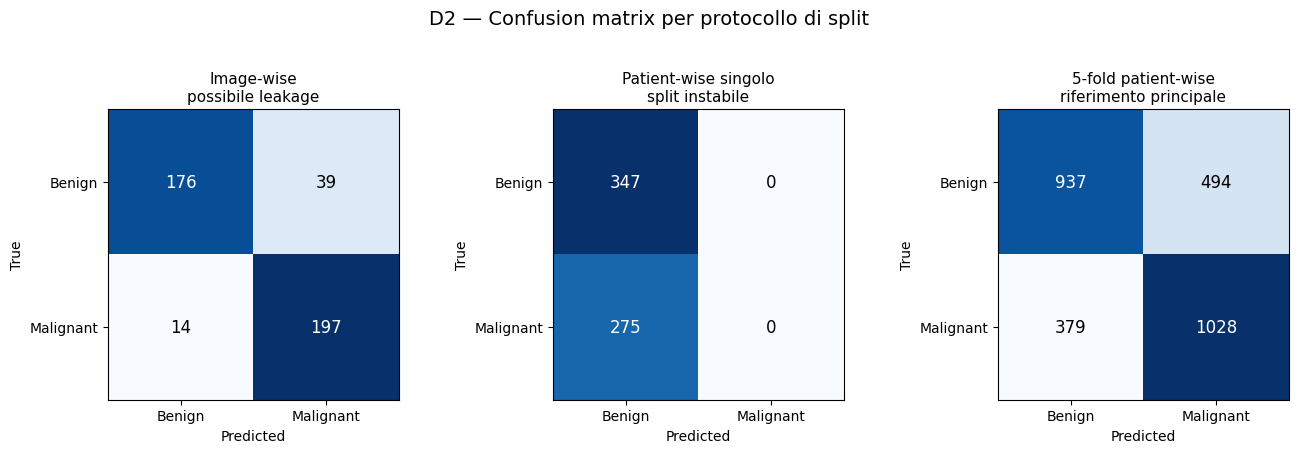

Figura salvata in: /content/drive/MyDrive/HistoBreastNet/results/02_baseline_cnn/figures/d2_split_confusion_matrices_comparison.png


In [4]:
# ==============================
# D2 — Confusion matrices comparison
# ==============================

def cm_from_row(row):
    return np.array([
        [int(row["tn"]), int(row["fp"])],
        [int(row["fn"]), int(row["tp"])]
    ])

cm_image = cm_from_row(image_row)
cm_patient = cm_from_row(patient_row)

kfold_counts = kfold_df[count_cols].sum()
cm_kfold = np.array([
    [int(kfold_counts["tn"]), int(kfold_counts["fp"])],
    [int(kfold_counts["fn"]), int(kfold_counts["tp"])]
])

matrices = [
    ("Image-wise\npossibile leakage", cm_image),
    ("Patient-wise singolo\nsplit instabile", cm_patient),
    ("5-fold patient-wise\nriferimento principale", cm_kfold)
]

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))

for ax, (title, cm) in zip(axes, matrices):
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title, fontsize=11)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Benign", "Malignant"])
    ax.set_yticklabels(["Benign", "Malignant"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    max_val = cm.max()
    for i in range(2):
        for j in range(2):
            value = cm[i, j]
            color = "white" if value > max_val / 2 else "black"
            ax.text(j, i, str(value), ha="center", va="center", color=color, fontsize=12)

fig.suptitle("D2 — Confusion matrix per protocollo di split", fontsize=14, y=1.05)
fig.tight_layout()

out_png = FIGURES_DIR / "d2_split_confusion_matrices_comparison.png"
out_pdf = FIGURES_DIR / "d2_split_confusion_matrices_comparison.pdf"
fig.savefig(out_png, dpi=200, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()

print(f"Figura salvata in: {out_png}")

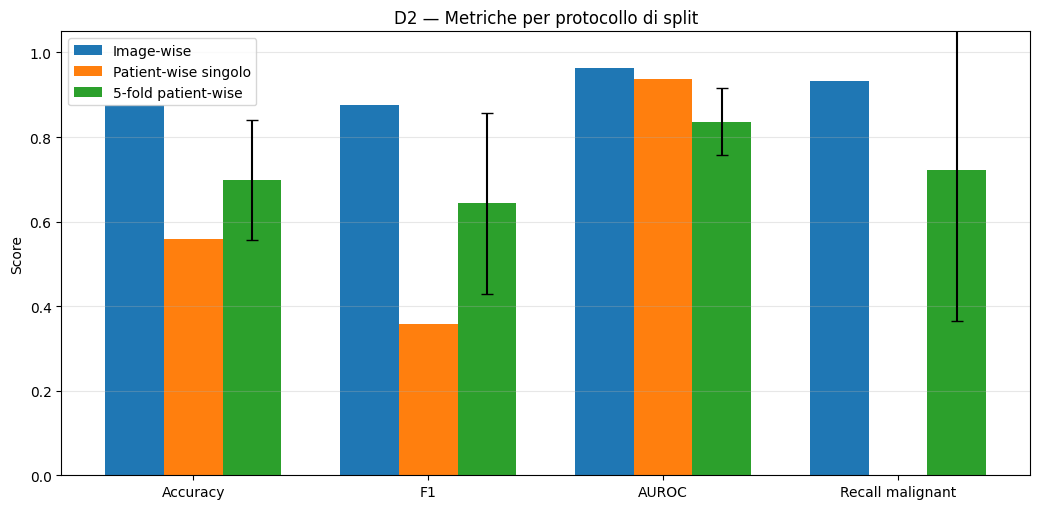

Figura salvata in: /content/drive/MyDrive/HistoBreastNet/results/02_baseline_cnn/figures/d2_split_metric_comparison.png


In [5]:
# ==============================
# D2 — Metric comparison bar plot
# ==============================

plot_metrics = ["accuracy", "f1", "auroc", "recall_malignant"]
metric_labels = {
    "accuracy": "Accuracy",
    "f1": "F1",
    "auroc": "AUROC",
    "recall_malignant": "Recall malignant"
}

plot_data = []

for metric in plot_metrics:
    plot_data.append({
        "Protocollo": "Image-wise",
        "Metrica": metric_labels[metric],
        "Valore": float(image_row[metric]),
        "Std": 0.0
    })
    plot_data.append({
        "Protocollo": "Patient-wise singolo",
        "Metrica": metric_labels[metric],
        "Valore": float(patient_row[metric]),
        "Std": 0.0
    })
    plot_data.append({
        "Protocollo": "5-fold patient-wise",
        "Metrica": metric_labels[metric],
        "Valore": float(kfold_mean[metric]),
        "Std": float(kfold_std[metric])
    })

plot_df = pd.DataFrame(plot_data)

protocols = ["Image-wise", "Patient-wise singolo", "5-fold patient-wise"]
metrics = [metric_labels[m] for m in plot_metrics]

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10.5, 5.2))

for idx, protocol in enumerate(protocols):
    subset = plot_df[plot_df["Protocollo"] == protocol]
    values = [subset[subset["Metrica"] == metric]["Valore"].iloc[0] for metric in metrics]
    errors = [subset[subset["Metrica"] == metric]["Std"].iloc[0] for metric in metrics]

    ax.bar(
        x + (idx - 1) * width,
        values,
        width,
        yerr=errors if protocol == "5-fold patient-wise" else None,
        capsize=4 if protocol == "5-fold patient-wise" else 0,
        label=protocol
    )

ax.set_title("D2 — Metriche per protocollo di split")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
ax.legend()

fig.tight_layout()

out_png = FIGURES_DIR / "d2_split_metric_comparison.png"
out_pdf = FIGURES_DIR / "d2_split_metric_comparison.pdf"
fig.savefig(out_png, dpi=200, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()

print(f"Figura salvata in: {out_png}")

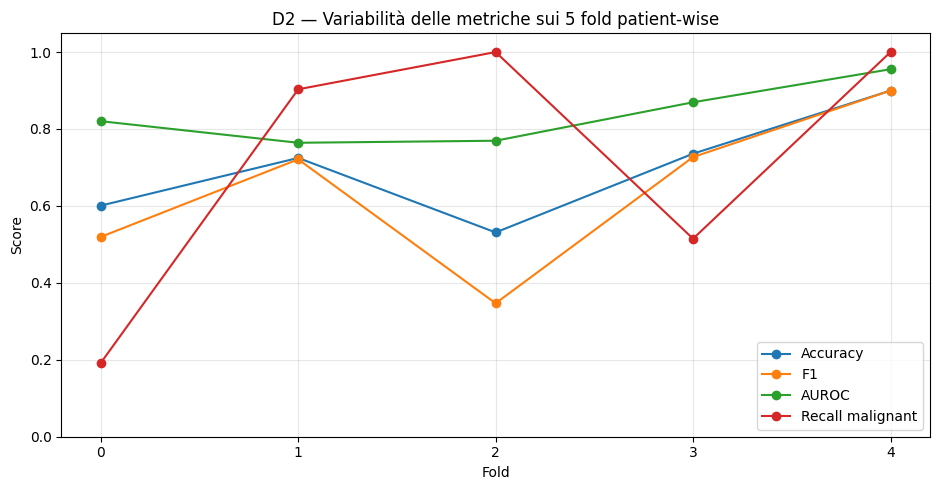

Figura salvata in: /content/drive/MyDrive/HistoBreastNet/results/02_baseline_cnn/figures/d2_kfold_metric_variability.png


In [6]:
# ==============================
# D2 — Fold variability plot
# ==============================

fold_plot_df = kfold_df.copy()
fold_plot_df["fold"] = fold_plot_df["fold"].astype(int)

fig, ax = plt.subplots(figsize=(9.5, 5))

for metric in plot_metrics:
    ax.plot(
        fold_plot_df["fold"],
        fold_plot_df[metric],
        marker="o",
        label=metric_labels[metric]
    )

ax.set_title("D2 — Variabilità delle metriche sui 5 fold patient-wise")
ax.set_xlabel("Fold")
ax.set_ylabel("Score")
ax.set_xticks(sorted(fold_plot_df["fold"].unique()))
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()

out_png = FIGURES_DIR / "d2_kfold_metric_variability.png"
out_pdf = FIGURES_DIR / "d2_kfold_metric_variability.pdf"
fig.savefig(out_png, dpi=200, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()

print(f"Figura salvata in: {out_png}")

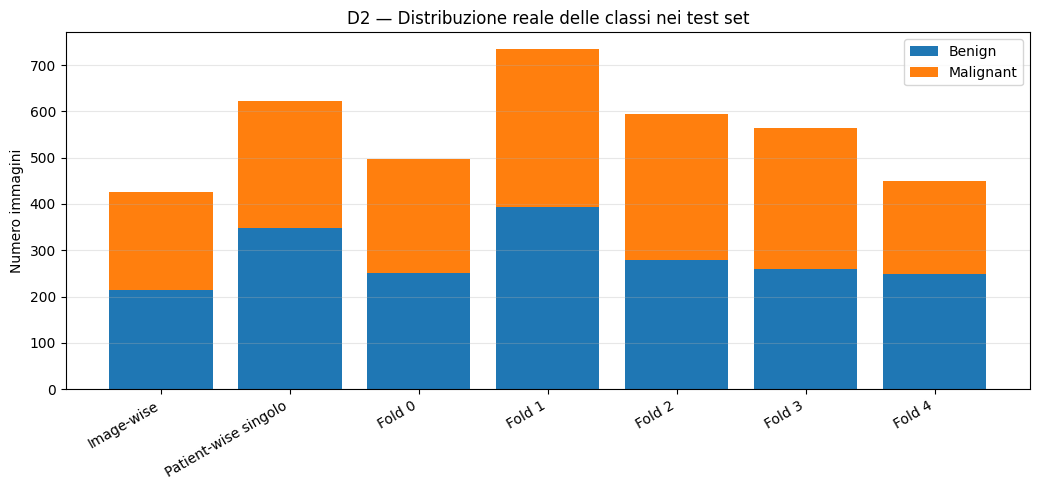

Figura salvata in: /content/drive/MyDrive/HistoBreastNet/results/02_baseline_cnn/figures/d2_test_class_distribution.png


In [7]:
# ==============================
# D2 — True class distribution by split/fold
# ==============================

dist_rows = []

# Image-wise
dist_rows.append({
    "Protocollo": "Image-wise",
    "Benign": int(image_row["tn"] + image_row["fp"]),
    "Malignant": int(image_row["fn"] + image_row["tp"])
})

# Patient-wise singolo
dist_rows.append({
    "Protocollo": "Patient-wise singolo",
    "Benign": int(patient_row["tn"] + patient_row["fp"]),
    "Malignant": int(patient_row["fn"] + patient_row["tp"])
})

# K-fold singoli
for _, row in fold_plot_df.iterrows():
    dist_rows.append({
        "Protocollo": f"Fold {int(row['fold'])}",
        "Benign": int(row["tn"] + row["fp"]),
        "Malignant": int(row["fn"] + row["tp"])
    })

dist_df = pd.DataFrame(dist_rows)

fig, ax = plt.subplots(figsize=(10.5, 5))

x = np.arange(len(dist_df))
ax.bar(x, dist_df["Benign"], label="Benign")
ax.bar(x, dist_df["Malignant"], bottom=dist_df["Benign"], label="Malignant")

ax.set_title("D2 — Distribuzione reale delle classi nei test set")
ax.set_ylabel("Numero immagini")
ax.set_xticks(x)
ax.set_xticklabels(dist_df["Protocollo"], rotation=30, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

out_png = FIGURES_DIR / "d2_test_class_distribution.png"
out_pdf = FIGURES_DIR / "d2_test_class_distribution.pdf"
fig.savefig(out_png, dpi=200, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()

print(f"Figura salvata in: {out_png}")

### Interpretazione dei risultati D2

Il confronto mostra che lo **split image-wise** produce prestazioni elevate, ma questa valutazione può essere ottimistica perché non garantisce la separazione dei pazienti tra training e test.

Lo **split patient-wise singolo** evita il patient leakage, ma risulta fortemente dipendente dalla specifica divisione dei pazienti. In questo caso la recall sulla classe maligna è pari a 0: il modello non riconosce immagini maligne alla soglia decisionale 0.5, pur avendo una AUROC elevata. Questo indica che la separabilità dei punteggi e la decisione finale a soglia fissa possono raccontare aspetti diversi del comportamento del modello.

Il **5-fold patient-wise** è quindi il riferimento principale per D2: mantiene la separazione tra pazienti e riduce la dipendenza da un singolo split. La forma **media ± deviazione standard** mostra sia la prestazione media sia la variabilità tra fold.

In sintesi, la D2 evidenzia che la valutazione patient-wise è più realistica rispetto alla valutazione image-wise, ma produce prestazioni più basse e più variabili.

**Nota operativa (materiali per la presentazione).** Per le slide non servono tutti i grafici generati. I due elaborati principali sono `d2_split_comparison_summary.csv` (tabella di sintesi) e `d2_split_confusion_matrices_comparison.png` (figura visiva). Gli altri grafici — `d2_split_metric_comparison.png`, `d2_kfold_metric_variability.png` e `d2_test_class_distribution.png` — restano come materiale di supporto per il notebook e il report.

## Sezione 10 — Lettura dei risultati per D2

- **image-wise**: stima potenzialmente **ottimistica** (patch dello stesso paziente possono ricadere sia in train sia in test); utile solo come limite superiore, non come misura di generalizzazione.
- **patient-wise (singolo split)**: più rigoroso, ma con circa 5 pazienti in test la varianza è alta e un singolo valore non è affidabile.
- **k-fold patient-wise (media ± std)**: è il riferimento per D2. La deviazione standard tra le fold quantifica l'incertezza dovuta al basso numero di pazienti e va **sempre** riportata accanto alla media.
- Per la classe maligna si privilegia **recall_malignant** (sensibilità): in ambito clinico un falso negativo pesa più di un falso positivo.

**Confronto con il transfer learning (D1).** `cnn_baseline_metrics.csv` e la sintesi k-fold costituiscono i termini di paragone per il transfer learning valutato nel notebook 03, che deve usare **le stesse fold** per un confronto equo tra CNN da zero e transfer, a parità di split ed efficienza.

## Output prodotti

- `results/02_baseline_cnn/tables/cnn_baseline_metrics.csv`: metriche complete per ogni run (schema fisso).
- `results/02_baseline_cnn/tables/cnn_baseline_kfold_summary.csv`: sintesi media ± std sulle 5 fold.
- `results/02_baseline_cnn/predictions/cnn_baseline_predictions.csv`: predizioni per immagine (out-of-fold) della baseline.
- `results/02_baseline_cnn/figures/cnn_kfold_confusion_matrix.png`: confusion matrix aggregata sulle 5 fold.
- `results/02_baseline_cnn/tables/d2_split_comparison_summary.csv`: tabella di confronto D2 tra i tre protocolli.
- `results/02_baseline_cnn/figures/d2_split_confusion_matrices_comparison.png` (+ `.pdf`): confusion matrix affiancate per i tre protocolli.
- `results/02_baseline_cnn/figures/d2_split_metric_comparison.png` (+ `.pdf`): confronto delle metriche per protocollo.
- `results/02_baseline_cnn/figures/d2_kfold_metric_variability.png` (+ `.pdf`): variabilità delle metriche sui 5 fold.
- `results/02_baseline_cnn/figures/d2_test_class_distribution.png` (+ `.pdf`): distribuzione reale delle classi nei test set.
- `experiments/<timestamp>_.../`: una cartella per run con `config.json`, `model.keras`, `training_log.csv` e `metrics.csv`.

Questi file costituiscono la baseline di riferimento per il confronto con il transfer learning del notebook 03, da valutare sulle stesse fold.